# Chest X-Ray Pneumonia Classification using Transfer Learning

## 1.Project Overview

Pneumonia is one of the leading causes of respiratory infections worldwide. Early diagnosis plays an important role in improving patient outcomes and reducing mortality.

In this project, transfer learning techniques are applied to classify chest X-ray images into two categories: **Normal** and **Pneumonia**.

Several experiments are conducted to investigate how different transfer learning strategies affect classification performance. These experiments include a baseline ResNet50 model, data augmentation, fine-tuning, and DenseNet121.

The models are evaluated using Accuracy, Precision, Recall, F1-score, and Confusion Matrix to provide a comprehensive performance comparison.

##2.Objectives

The objectives of this project are:

- Develop a binary image classification model for chest X-ray images.
- Apply transfer learning using pretrained convolutional neural networks.
- Compare different transfer learning strategies.
- Analyze the impact of data augmentation and fine-tuning.
- Compare the performance of ResNet50 and DenseNet121.

## 3.Project Workflow

The workflow of this project consists of the following steps:

1. Import required libraries
2. Prepare the dataset
3. Explore the dataset
4. Apply image preprocessing
5. Create DataLoaders
6. Train a baseline ResNet50 model
7. Evaluate the baseline model
8. Apply data augmentation
9. Apply fine-tuning
10. Train a DenseNet121 model
11. Compare all experiments
12. Draw conclusions

# 4. Import Libraries

The following libraries are imported for data processing, visualization, deep learning, and model evaluation.

Only the required libraries are included to keep the notebook clean and organized.

In [17]:
from pathlib import Path
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt


import torch
import torch.nn as nn

from torch.utils.data import DataLoader

from torchvision import datasets
from torchvision import transforms

from torchvision.models import (
    resnet50,
    ResNet50_Weights,
    densenet121,
    DenseNet121_Weights
)


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# 5. Set Random Seed

To improve reproducibility, a fixed random seed is used throughout the project.

Setting the random seed helps reduce variations caused by random initialization, data shuffling, and other stochastic processes during model training.

In [18]:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# 6. Configure the Computing Device

Deep learning models can be trained on either a CPU or a GPU.

In this project, the available hardware is detected automatically. If a CUDA-enabled GPU is available, it will be used to accelerate model training. Otherwise, the model will run on the CPU.

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


7. Extract the Dataset

The dataset is uploaded as a compressed ZIP file. Before loading the images, the archive must be extracted so that the folder structure can be accessed by PyTorch.

In [20]:
from zipfile import ZipFile

zip_path = "/content/chestxray (2).zip"

with ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [21]:
from pathlib import Path

dataset_path = Path("/content/chestxray")

print(dataset_path)

/content/chestxray


8. Define the Dataset Path
After extracting the dataset, the root directory is defined once and reused throughout the notebook. This approach improves readability and makes the code easier to maintain.

9. Verify the Dataset Structure
Before training the model, it is important to verify that the dataset has been extracted correctly and that the expected directory structure is available.

In [22]:
print("Root folders:", list(dataset_path.iterdir()))

print("\nTrain folders:", list((dataset_path / "train").iterdir()))

print("\nValidation folders:", list((dataset_path / "val").iterdir()))

print("\nTest folders:", list((dataset_path / "test").iterdir()))

Root folders: [PosixPath('/content/chestxray/train'), PosixPath('/content/chestxray/test'), PosixPath('/content/chestxray/val')]

Train folders: [PosixPath('/content/chestxray/train/pneumonia'), PosixPath('/content/chestxray/train/normal')]

Validation folders: [PosixPath('/content/chestxray/val/pneumonia'), PosixPath('/content/chestxray/val/normal')]

Test folders: [PosixPath('/content/chestxray/test/pneumonia'), PosixPath('/content/chestxray/test/normal')]


# 10. Explore the Dataset

Before training the models, it is important to understand the structure of the dataset.

This section examines the number of images in each subset and class. Understanding the data distribution helps identify potential class imbalance and provides a better understanding of the dataset.

In [23]:
train_normal = len(list((dataset_path / "train" / "normal").glob("*")))
train_pneumonia = len(list((dataset_path / "train" / "pneumonia").glob("*")))

val_normal = len(list((dataset_path / "val" / "normal").glob("*")))
val_pneumonia = len(list((dataset_path / "val" / "pneumonia").glob("*")))

test_normal = len(list((dataset_path / "test" / "normal").glob("*")))
test_pneumonia = len(list((dataset_path / "test" / "pneumonia").glob("*")))

print("Training Set")
print(f"Normal     : {train_normal}")
print(f"Pneumonia  : {train_pneumonia}")

print("\nValidation Set")
print(f"Normal     : {val_normal}")
print(f"Pneumonia  : {val_pneumonia}")

print("\nTest Set")
print(f"Normal     : {test_normal}")
print(f"Pneumonia  : {test_pneumonia}")

Training Set
Normal     : 56
Pneumonia  : 56

Validation Set
Normal     : 14
Pneumonia  : 14

Test Set
Normal     : 30
Pneumonia  : 30


# 11. Dataset Summary

The following table summarizes the number of images in each dataset split.

This overview helps verify that the dataset has been prepared correctly before training the models.

In [24]:
dataset_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Normal": [train_normal, val_normal, test_normal],
    "Pneumonia": [train_pneumonia, val_pneumonia, test_pneumonia]
})

dataset_summary["Total"] = (
    dataset_summary["Normal"] +
    dataset_summary["Pneumonia"]
)

dataset_summary

,Dataset,Normal,Pneumonia,Total
0,Training,56,56,112
1,Validation,14,14,28
2,Test,30,30,60


# 12. Dataset Distribution

The following bar chart illustrates the number of Normal and Pneumonia images in each dataset split.

This visualization provides a quick overview of the class distribution.

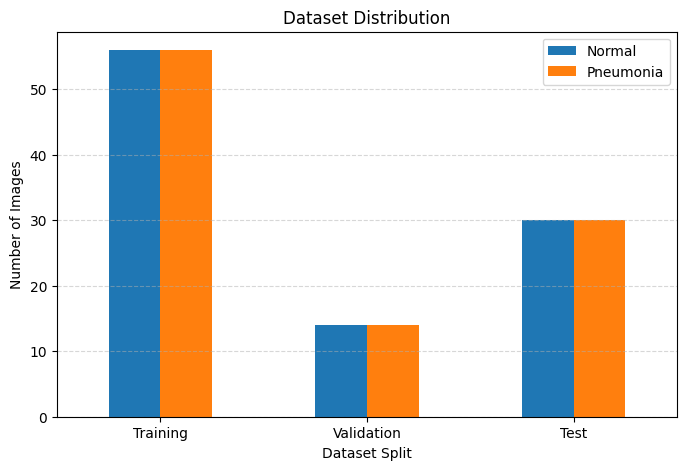

In [25]:
dataset_summary.set_index("Dataset")[["Normal", "Pneumonia"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Dataset Distribution")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# 13. Visualize Sample Images

Before training the deep learning models, several sample images are displayed from each class.

This step provides a visual inspection of the dataset and helps confirm that the images have been loaded correctly.

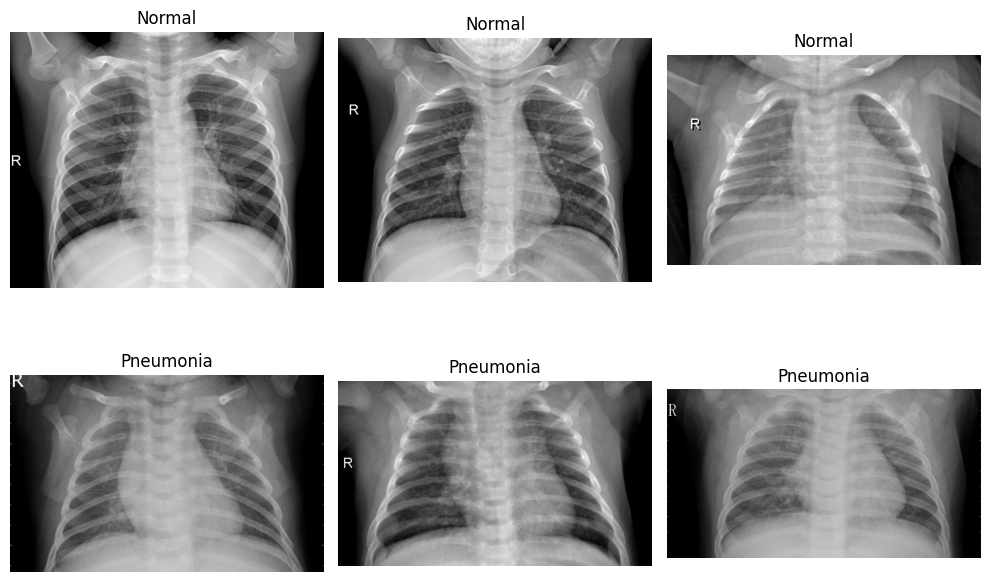

In [26]:
from PIL import Image

normal_images = list((dataset_path / "train" / "normal").glob("*"))
pneumonia_images = list((dataset_path / "train" / "pneumonia").glob("*"))

fig, axes = plt.subplots(2, 3, figsize=(10, 7))

# Normal images
for i in range(3):
    img = Image.open(normal_images[i])

    axes[0, i].imshow(img, cmap="gray")
    axes[0, i].set_title("Normal")
    axes[0, i].axis("off")

# Pneumonia images
for i in range(3):
    img = Image.open(pneumonia_images[i])

    axes[1, i].imshow(img, cmap="gray")
    axes[1, i].set_title("Pneumonia")
    axes[1, i].axis("off")

plt.tight_layout()

plt.show()

# 14. Image Preprocessing

Before training the neural networks, all images are preprocessed.

The preprocessing pipeline resizes the images, converts them into tensors, and normalizes pixel values using the ImageNet statistics. These operations ensure compatibility with the pretrained models.

In [27]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 15. Load the Dataset

The dataset is loaded using the `ImageFolder` class provided by PyTorch.

This class automatically assigns class labels according to the folder names and applies the preprocessing pipeline defined earlier.

In [28]:
train_dataset = datasets.ImageFolder(
    root=dataset_path / "train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root=dataset_path / "val",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=dataset_path / "test",
    transform=transform
)

# 16. Verify the Loaded Dataset

After loading the dataset, a few basic properties are examined to verify that the images and class labels have been loaded correctly.

In [29]:
print("Classes :", train_dataset.classes)

print("Training Images   :", len(train_dataset))

print("Validation Images :", len(val_dataset))

print("Test Images       :", len(test_dataset))

Classes : ['normal', 'pneumonia']
Training Images   : 112
Validation Images : 28
Test Images       : 60


# 17. Create DataLoaders

The datasets are wrapped into PyTorch DataLoaders.

Instead of processing the entire dataset at once, the images are divided into small batches. This improves memory efficiency and enables the model to learn iteratively during training.

The training dataset is shuffled before each epoch to improve generalization, while the validation and test datasets remain in their original order.

In [30]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 18. Verify the DataLoaders

Before training the models, one batch is retrieved from the training DataLoader.

This verification step confirms that the images and labels have the expected dimensions.

In [31]:
images, labels = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

Image batch shape : torch.Size([16, 3, 224, 224])
Label batch shape : torch.Size([16])


# 19. Build the Baseline ResNet50 Model

A pretrained ResNet50 model is used as the baseline architecture.

The original classification layer is replaced with a new fully connected layer consisting of two output neurons, corresponding to the Normal and Pneumonia classes.

This approach allows the model to leverage previously learned visual features while adapting to the current classification task.

In [32]:
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


In [33]:
# Replace the final classification layer

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

# 20. Define the Loss Function and Optimizer

Before training begins, a loss function and an optimization algorithm must be defined.

The CrossEntropyLoss function is used to measure the classification error, while the Adam optimizer updates the model parameters during backpropagation.

In [34]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

# 21.Improved Training Function

The training function is extended with an early stopping mechanism to prevent unnecessary training after the validation loss stops improving.

The model parameters corresponding to the lowest validation loss are automatically saved and restored after training. This improves training efficiency and helps retain the best-performing model.

In [35]:
import copy

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=10,
    patience=3
):

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(epochs):



        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)



        model.eval()

        running_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = running_loss / len(val_loader)
        val_acc = correct / total

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"| Train Loss: {train_loss:.4f} "
            f"| Train Acc: {train_acc:.4f} "
            f"| Val Loss: {val_loss:.4f} "
            f"| Val Acc: {val_acc:.4f}"
        )



        if val_loss < best_val_loss:

            best_val_loss = val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0

        else:

            patience_counter += 1

            if patience_counter >= patience:

                print("\nEarly stopping triggered.")
                break

    model.load_state_dict(best_model_weights)

    return history

# 22. Define the Evaluation Function

The evaluation function is extended to compute additional performance metrics.

Besides Accuracy, Precision, Recall, F1-score, and the Confusion Matrix, the Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC) score are also calculated.

These metrics provide a more comprehensive assessment of the model's classification performance.

In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [37]:
# =====================================================
# Evaluation Function
# =====================================================

def evaluate_model(model, test_loader, device):

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            probabilities = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_probabilities.extend(probabilities[:, 1].cpu().numpy())

    # ---------------- Classification Metrics ----------------

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions)
    recall = recall_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions)
    auc = roc_auc_score(all_labels, all_probabilities)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUC Score: {auc:.4f}")

    # ---------------- Classification Report ----------------

    print("\nClassification Report\n")

    print(classification_report(
        all_labels,
        all_predictions
    ))

    # ---------------- Confusion Matrix ----------------

    cm = confusion_matrix(
        all_labels,
        all_predictions
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(cmap="Blues")

    plt.title("Confusion Matrix")

    plt.show()

    # ---------------- ROC Curve ----------------

    fpr, tpr, _ = roc_curve(
        all_labels,
        all_probabilities
    )

    plt.figure(figsize=(6,6))

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"AUC = {auc:.3f}"
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle="--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()

    plt.grid(True)

    plt.show()

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }

# 23. Baseline Experiment

The baseline experiment uses a pretrained ResNet50 model without data augmentation or fine-tuning.

Its performance serves as the reference for all subsequent experiments.

In [38]:
model = model.to(device)

In [39]:
history_baseline = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=10
)

Epoch [1/10] | Train Loss: 0.4409 | Train Acc: 0.7857 | Val Loss: 1.9914 | Val Acc: 0.7143
Epoch [2/10] | Train Loss: 0.1318 | Train Acc: 0.9643 | Val Loss: 3.4328 | Val Acc: 0.8571
Epoch [3/10] | Train Loss: 0.1777 | Train Acc: 0.9196 | Val Loss: 4.8830 | Val Acc: 0.7857
Epoch [4/10] | Train Loss: 0.1162 | Train Acc: 0.9732 | Val Loss: 1.4826 | Val Acc: 0.8571
Epoch [5/10] | Train Loss: 0.3958 | Train Acc: 0.8571 | Val Loss: 2.5565 | Val Acc: 0.8214
Epoch [6/10] | Train Loss: 0.1552 | Train Acc: 0.9375 | Val Loss: 1.4247 | Val Acc: 0.8929
Epoch [7/10] | Train Loss: 0.0344 | Train Acc: 1.0000 | Val Loss: 0.6758 | Val Acc: 0.8571
Epoch [8/10] | Train Loss: 0.0147 | Train Acc: 1.0000 | Val Loss: 0.3885 | Val Acc: 0.8571
Epoch [9/10] | Train Loss: 0.0628 | Train Acc: 0.9911 | Val Loss: 0.1585 | Val Acc: 0.8929
Epoch [10/10] | Train Loss: 0.0423 | Train Acc: 0.9911 | Val Loss: 0.1038 | Val Acc: 0.9643


# 24. Visualize the Training History

The training history is visualized using loss and accuracy curves.

These plots provide insights into the learning process and help identify potential issues such as overfitting or underfitting.

In [40]:
def plot_history(history):

    epochs = range(1, len(history["train_loss"]) + 1)

    # ---------------- Loss ----------------

    plt.figure(figsize=(7,5))

    plt.plot(epochs, history["train_loss"], label="Training Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")

    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()

    plt.grid(True)

    plt.show()

    plt.figure(figsize=(7,5))

    plt.plot(epochs, history["train_acc"], label="Training Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")

    plt.title("Accuracy Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.grid(True)

    plt.show()

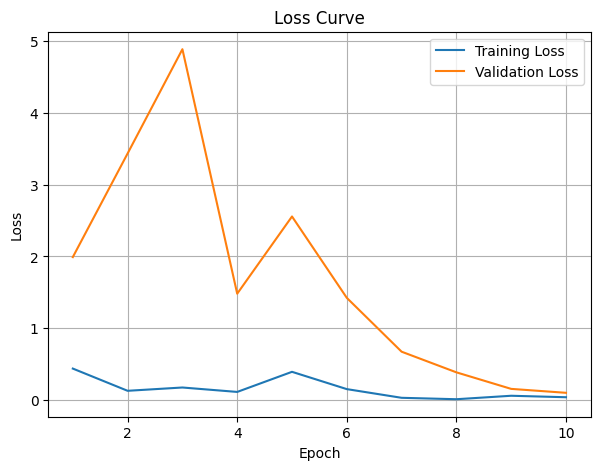

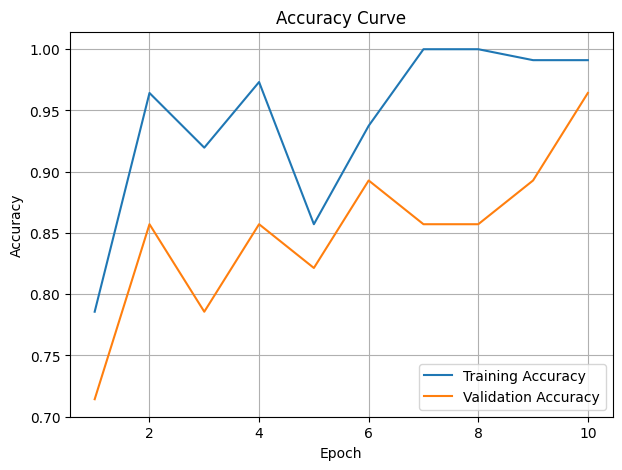

In [41]:
plot_history(history_baseline)

# 25. Experiment 2: Data Augmentation

In this experiment, data augmentation is applied only to the training dataset.

Random transformations generate different variations of the original images, allowing the model to learn more robust visual features and improve generalization.

In [42]:
train_transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )

])

In [43]:
train_dataset_aug = datasets.ImageFolder(
    root=dataset_path/"train",
    transform=train_transform
)

val_dataset_aug = datasets.ImageFolder(
    root=dataset_path/"val",
    transform=transform
)

test_dataset_aug = datasets.ImageFolder(
    root=dataset_path/"test",
    transform=transform
)

In [44]:
train_loader_aug = DataLoader(
    train_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader_aug = DataLoader(
    val_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader_aug = DataLoader(
    test_dataset_aug,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [45]:
weights = ResNet50_Weights.DEFAULT

model_aug = resnet50(weights=weights)

model_aug.fc = nn.Linear(
    model_aug.fc.in_features,
    2
)

model_aug = model_aug.to(device)

In [46]:
criterion_aug = nn.CrossEntropyLoss()

optimizer_aug = torch.optim.Adam(
    model_aug.parameters(),
    lr=0.001
)

In [47]:
history_aug = train_model(
    model=model_aug,
    train_loader=train_loader_aug,
    val_loader=val_loader_aug,
    criterion=criterion_aug,
    optimizer=optimizer_aug,
    device=device,
    epochs=10
)

Epoch [1/10] | Train Loss: 0.5190 | Train Acc: 0.7679 | Val Loss: 3.6169 | Val Acc: 0.5000
Epoch [2/10] | Train Loss: 0.2638 | Train Acc: 0.9018 | Val Loss: 1.2022 | Val Acc: 0.8214
Epoch [3/10] | Train Loss: 0.1405 | Train Acc: 0.9554 | Val Loss: 2.0104 | Val Acc: 0.8214
Epoch [4/10] | Train Loss: 0.1715 | Train Acc: 0.9286 | Val Loss: 1.8084 | Val Acc: 0.8929
Epoch [5/10] | Train Loss: 0.3730 | Train Acc: 0.8839 | Val Loss: 0.5912 | Val Acc: 0.8929
Epoch [6/10] | Train Loss: 0.1706 | Train Acc: 0.9554 | Val Loss: 0.0550 | Val Acc: 0.9643
Epoch [7/10] | Train Loss: 0.1620 | Train Acc: 0.9286 | Val Loss: 58.9345 | Val Acc: 0.5714
Epoch [8/10] | Train Loss: 0.1736 | Train Acc: 0.9375 | Val Loss: 1.6235 | Val Acc: 0.8214
Epoch [9/10] | Train Loss: 0.2571 | Train Acc: 0.9107 | Val Loss: 0.2619 | Val Acc: 0.8929

Early stopping triggered.


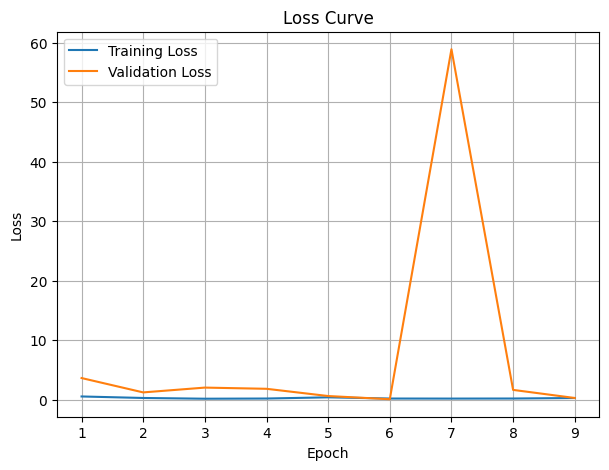

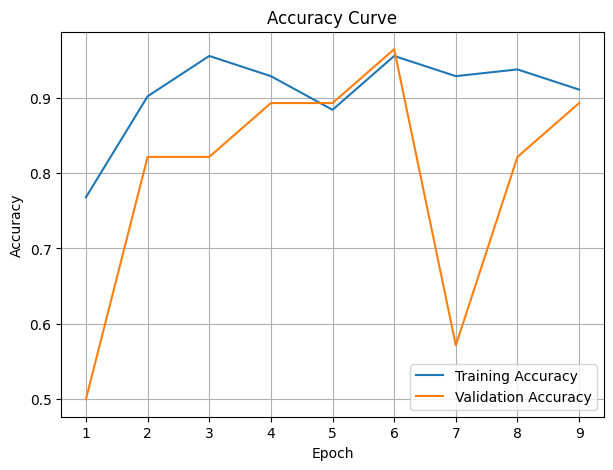

In [48]:
plot_history(history_aug)

Accuracy : 0.8000
Precision: 1.0000
Recall   : 0.6000
F1 Score : 0.7500
AUC Score: 0.9789

Classification Report

              precision    recall  f1-score   support

           0       0.71      1.00      0.83        30
           1       1.00      0.60      0.75        30

    accuracy                           0.80        60
   macro avg       0.86      0.80      0.79        60
weighted avg       0.86      0.80      0.79        60



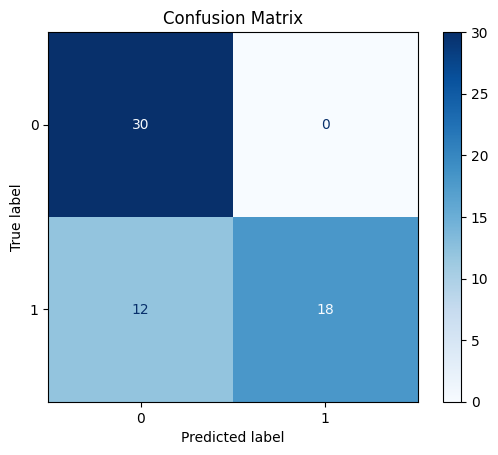

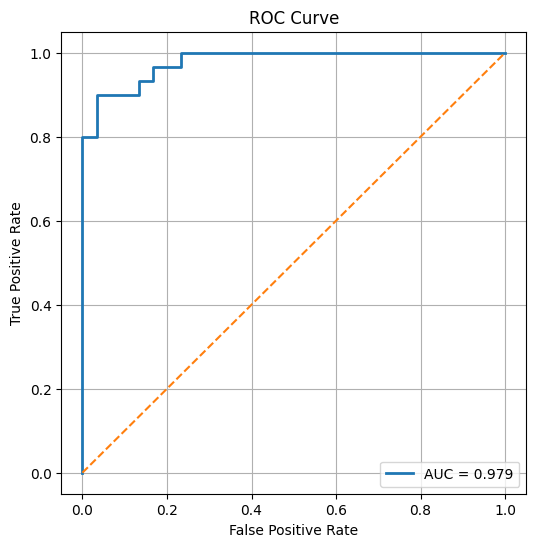

In [49]:
augmentation_results = evaluate_model(
    model_aug,
    test_loader_aug,
    device
)

# 26. Experiment 3: Fine-Tuning

In this experiment, the pretrained ResNet50 model is fine-tuned by unfreezing the final residual block.

Unlike the baseline experiment, the model is allowed to update part of its pretrained weights, enabling it to learn features that are more specific to chest X-ray classification.

In [50]:
weights = ResNet50_Weights.DEFAULT

model_ft = resnet50(weights=weights)

model_ft.fc = nn.Linear(
    model_ft.fc.in_features,
    2
)

In [51]:
for param in model_ft.parameters():
    param.requires_grad = False

In [52]:
for param in model_ft.layer4.parameters():
    param.requires_grad = True

In [53]:
for param in model_ft.fc.parameters():
    param.requires_grad = True

In [54]:
model_ft = model_ft.to(device)

In [55]:
criterion_ft = nn.CrossEntropyLoss()

optimizer_ft = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=1e-4
)

In [56]:
history_ft = train_model(
    model=model_ft,
    train_loader=train_loader_aug,
    val_loader=val_loader_aug,
    criterion=criterion_ft,
    optimizer=optimizer_ft,
    device=device,
    epochs=10
)

Epoch [1/10] | Train Loss: 0.6586 | Train Acc: 0.6250 | Val Loss: 0.6100 | Val Acc: 0.8571
Epoch [2/10] | Train Loss: 0.5674 | Train Acc: 0.8393 | Val Loss: 0.5243 | Val Acc: 0.9286
Epoch [3/10] | Train Loss: 0.4831 | Train Acc: 0.8661 | Val Loss: 0.4157 | Val Acc: 0.9286
Epoch [4/10] | Train Loss: 0.4017 | Train Acc: 0.8750 | Val Loss: 0.3504 | Val Acc: 0.9286
Epoch [5/10] | Train Loss: 0.2980 | Train Acc: 0.8839 | Val Loss: 0.3016 | Val Acc: 0.9286
Epoch [6/10] | Train Loss: 0.2921 | Train Acc: 0.9018 | Val Loss: 0.2657 | Val Acc: 0.9286
Epoch [7/10] | Train Loss: 0.2169 | Train Acc: 0.9554 | Val Loss: 0.2353 | Val Acc: 0.9643
Epoch [8/10] | Train Loss: 0.1665 | Train Acc: 0.9464 | Val Loss: 0.1738 | Val Acc: 0.9643
Epoch [9/10] | Train Loss: 0.1178 | Train Acc: 0.9732 | Val Loss: 0.1569 | Val Acc: 0.9286
Epoch [10/10] | Train Loss: 0.1861 | Train Acc: 0.9196 | Val Loss: 0.1564 | Val Acc: 0.9286


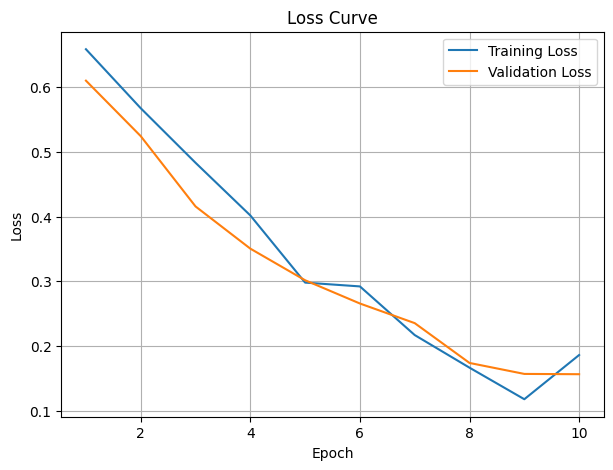

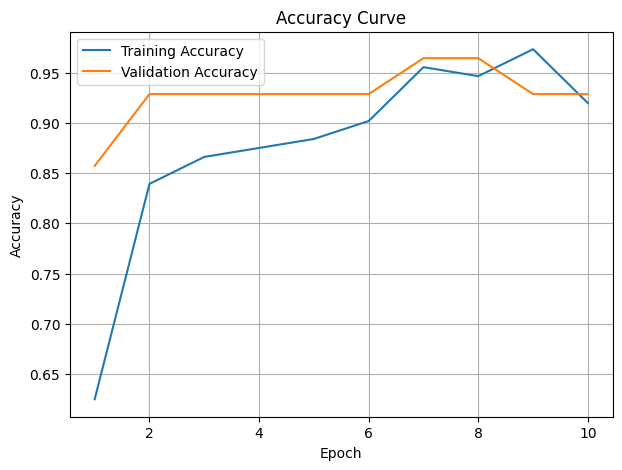

In [57]:
plot_history(history_ft)

Accuracy : 0.9500
Precision: 1.0000
Recall   : 0.9000
F1 Score : 0.9474
AUC Score: 0.9833

Classification Report

              precision    recall  f1-score   support

           0       0.91      1.00      0.95        30
           1       1.00      0.90      0.95        30

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



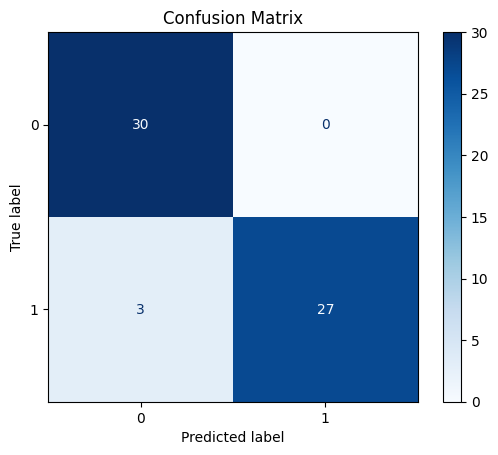

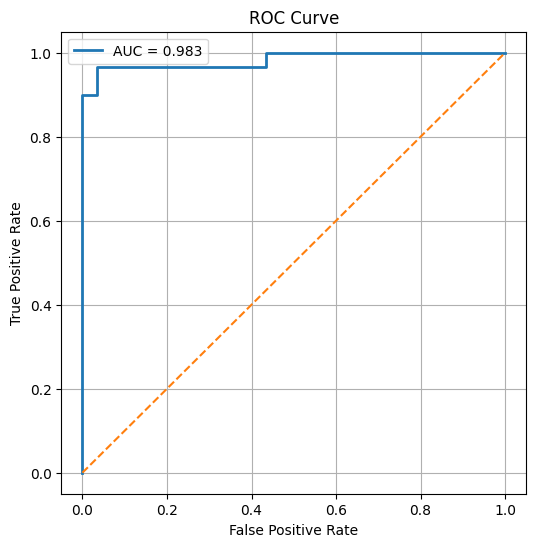

In [58]:
finetuning_results = evaluate_model(
    model_ft,
    test_loader_aug,
    device
)

# 27. Experiment 4: DenseNet121

In the final experiment, DenseNet121 is used instead of ResNet50.

DenseNet121 employs dense connections between layers, encouraging feature reuse and efficient information flow throughout the network.

The model is evaluated using the same preprocessing pipeline and training procedure to ensure a fair comparison.

In [59]:
weights = DenseNet121_Weights.DEFAULT

model_dense = densenet121(weights=weights)

model_dense.classifier = nn.Linear(
    model_dense.classifier.in_features,
    2
)

model_dense = model_dense.to(device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 118MB/s]


In [60]:
criterion_dense = nn.CrossEntropyLoss()

optimizer_dense = torch.optim.Adam(
    model_dense.parameters(),
    lr=0.001
)

In [61]:
history_dense = train_model(
    model=model_dense,
    train_loader=train_loader_aug,
    val_loader=val_loader_aug,
    criterion=criterion_dense,
    optimizer=optimizer_dense,
    device=device,
    epochs=10
)

Epoch [1/10] | Train Loss: 0.4863 | Train Acc: 0.7411 | Val Loss: 0.6794 | Val Acc: 0.7143
Epoch [2/10] | Train Loss: 0.3125 | Train Acc: 0.8482 | Val Loss: 0.3328 | Val Acc: 0.9643
Epoch [3/10] | Train Loss: 0.1284 | Train Acc: 0.9464 | Val Loss: 0.5191 | Val Acc: 0.8571
Epoch [4/10] | Train Loss: 0.2154 | Train Acc: 0.9375 | Val Loss: 0.6352 | Val Acc: 0.8214
Epoch [5/10] | Train Loss: 0.2141 | Train Acc: 0.9018 | Val Loss: 0.3675 | Val Acc: 0.8929

Early stopping triggered.


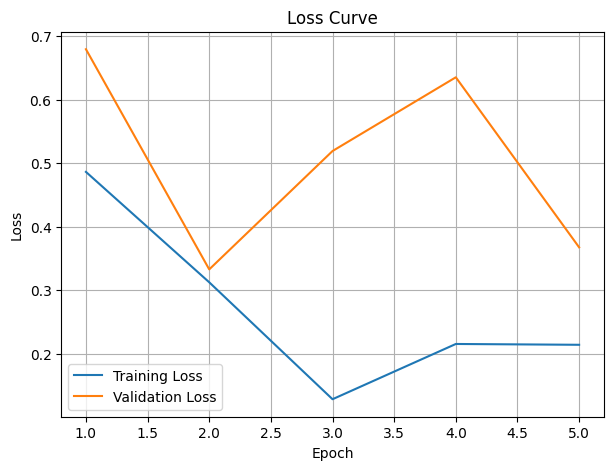

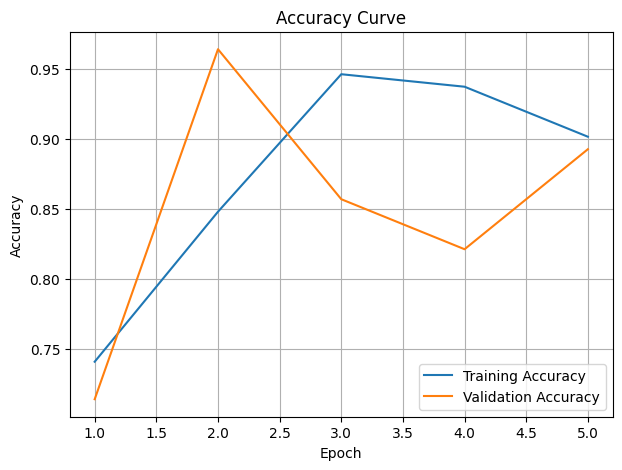

In [62]:
plot_history(history_dense)

Accuracy : 0.7500
Precision: 1.0000
Recall   : 0.5000
F1 Score : 0.6667
AUC Score: 0.9833

Classification Report

              precision    recall  f1-score   support

           0       0.67      1.00      0.80        30
           1       1.00      0.50      0.67        30

    accuracy                           0.75        60
   macro avg       0.83      0.75      0.73        60
weighted avg       0.83      0.75      0.73        60



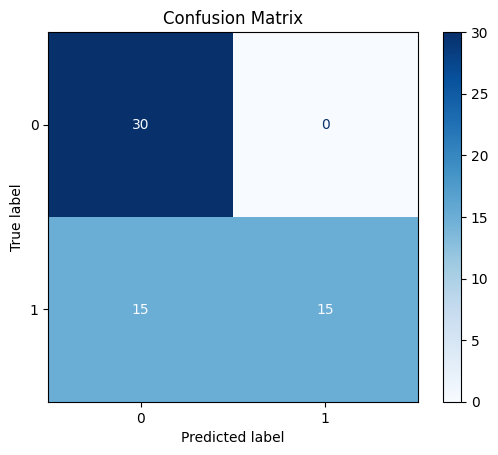

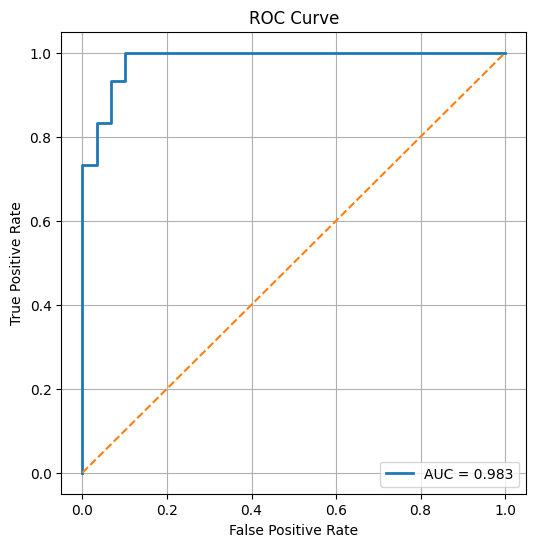

In [63]:
densenet_results = evaluate_model(
    model_dense,
    test_loader_aug,
    device
)

# 28. Compare All Models

The performance of all experiments is summarized in a single table using the same evaluation metrics.

The learning curves are also examined to determine whether the models generalize well or exhibit signs of overfitting.

Accuracy : 0.9667
Precision: 1.0000
Recall   : 0.9333
F1 Score : 0.9655
AUC Score: 0.9478

Classification Report

              precision    recall  f1-score   support

           0       0.94      1.00      0.97        30
           1       1.00      0.93      0.97        30

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60



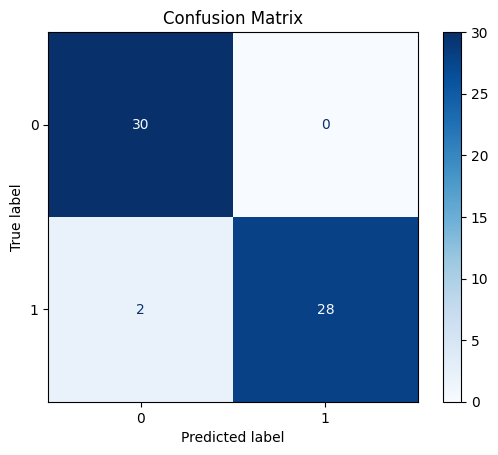

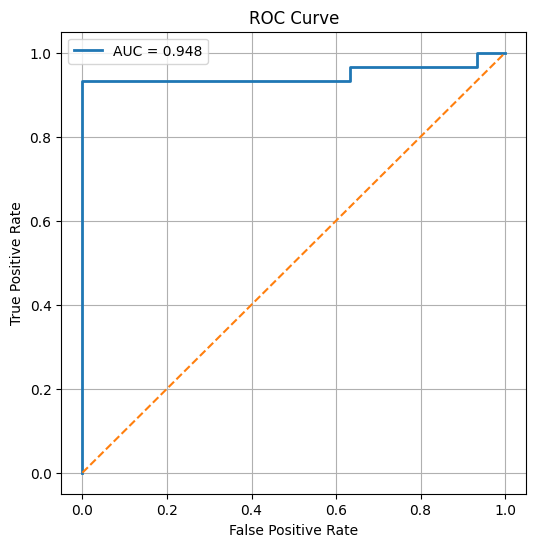

In [64]:
baseline_results = evaluate_model(
    model=model,
    test_loader=test_loader,
    device=device
)

In [66]:
# =====================================================
# Compare All Models
# =====================================================

comparison = pd.DataFrame({

    "Experiment": [
        "Baseline",
        "Data Augmentation",
        "Fine-Tuning",
        "DenseNet121"
    ],

    "Model": [
        "ResNet50",
        "ResNet50",
        "ResNet50",
        "DenseNet121"
    ],

    "Accuracy": [
        baseline_results["Accuracy"],
        augmentation_results["Accuracy"],
        finetuning_results["Accuracy"],
        densenet_results["Accuracy"]
    ],

    "Precision": [
        baseline_results["Precision"],
        augmentation_results["Precision"],
        finetuning_results["Precision"],
        densenet_results["Precision"]
    ],

    "Recall": [
        baseline_results["Recall"],
        augmentation_results["Recall"],
        finetuning_results["Recall"],
        densenet_results["Recall"]
    ],

    "F1-Score": [
        baseline_results["F1"],
        augmentation_results["F1"],
        finetuning_results["F1"],
        densenet_results["F1"]
    ],

    "AUC": [
        baseline_results["AUC"],
        augmentation_results["AUC"],
        finetuning_results["AUC"],
        densenet_results["AUC"]
    ]

})

comparison = comparison.round(4)

comparison

,Experiment,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Baseline,ResNet50,0.9667,1.0,0.9333,0.9655,0.9478
1,Data Augmentation,ResNet50,0.8000,1.0,0.6000,0.7500,0.9789
2,Fine-Tuning,ResNet50,0.9500,1.0,0.9000,0.9474,0.9833
3,DenseNet121,DenseNet121,0.7500,1.0,0.5000,0.6667,0.9833


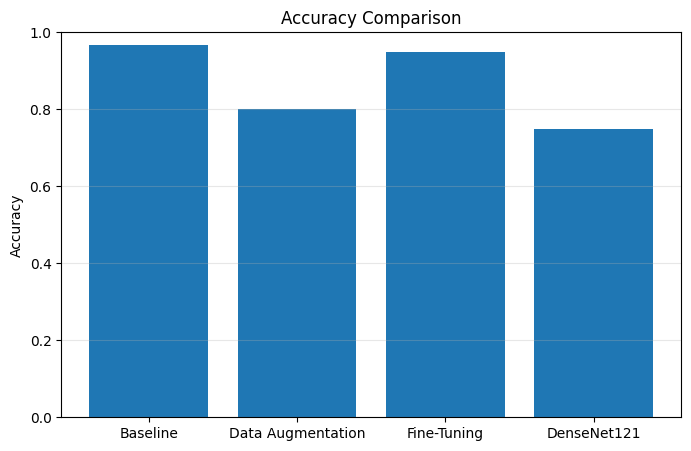

In [67]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Experiment"],
    comparison["Accuracy"]
)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.grid(axis="y", alpha=0.3)

plt.show()

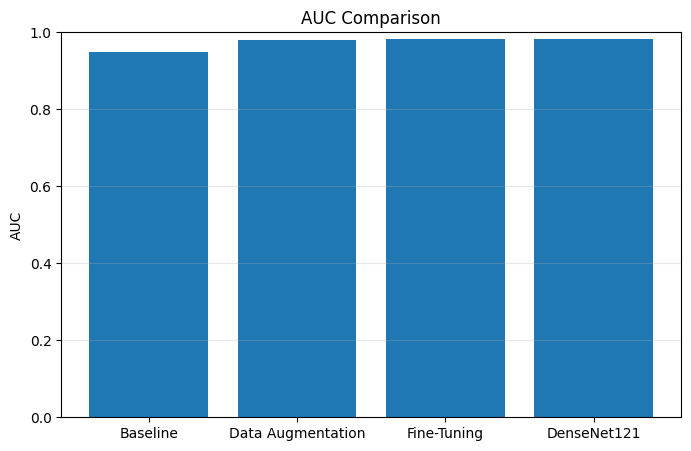

In [68]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Experiment"],
    comparison["AUC"]
)

plt.title("AUC Comparison")
plt.ylabel("AUC")
plt.ylim(0,1)

plt.grid(axis="y", alpha=0.3)

plt.show()

# 29. Discussion

This study compared four transfer learning strategies for pneumonia classification using chest X-ray images: a baseline ResNet50 model, data augmentation, fine-tuning, and DenseNet121.

Among all experiments, the baseline ResNet50 model achieved the highest overall performance with an accuracy of 96.67% and an F1-score of 96.55%. The fine-tuned ResNet50 model produced comparable results with an accuracy of 95.00% and an F1-score of 94.74%, indicating that additional fine-tuning did not provide a significant improvement for this dataset.

The data augmentation experiment resulted in lower classification performance. Although the ROC-AUC value remained high, the confusion matrix showed that several pneumonia cases were misclassified. This suggests that the selected augmentation strategy may have introduced additional variability that was not beneficial for the limited dataset.

DenseNet121 also achieved a high ROC-AUC score but showed lower classification accuracy than the ResNet50 models. The confusion matrix indicated that a larger number of pneumonia images were incorrectly classified, reducing its overall performance.

Overall, the results suggest that transfer learning with a pretrained ResNet50 backbone is sufficient for this balanced chest X-ray dataset without requiring extensive fine-tuning or more complex architectures.

# 30. Overfitting Analysis

The learning curves were analyzed to assess possible overfitting.

The baseline ResNet50 and fine-tuned ResNet50 models showed similar trends between training and validation accuracy throughout training. Validation loss also decreased over time, indicating stable learning without significant overfitting.

The DenseNet121 model exhibited minor fluctuations in validation performance, but no persistent divergence between the training and validation curves was observed.

The data augmentation experiment showed an unstable validation loss during one epoch. However, this behavior was temporary and is likely related to the limited validation set size rather than severe overfitting.

Overall, the experiments did not exhibit substantial overfitting, and the implemented early stopping strategy helped prevent unnecessary training after validation performance stopped improving.

# 31. Limitations

Several limitations should be considered when interpreting the results.

- The dataset contains a relatively small number of chest X-ray images.
- The experiments were conducted using a single predefined train, validation, and test split.
- Cross-validation was not incorporated because the dataset was already organized into predefined subsets.
- Only CNN-based transfer learning architectures were evaluated.
- The experiments focused solely on image classification and did not include explainable AI or automatic report generation.

# 32. Future Work

Future studies may improve the proposed approach in several directions.

- Apply stratified k-fold cross-validation to obtain more robust estimates of model generalization.
- Evaluate additional deep learning architectures, such as EfficientNet and Vision Transformers.
- Investigate explainable AI techniques, including Grad-CAM, to improve model interpretability.
- Explore Vision-Language Models (VLMs) capable of jointly analyzing chest X-ray images and generating preliminary radiology reports.
- Validate the proposed models on larger and more diverse medical imaging datasets collected from multiple institutions.

# 33. Conclusion

This study investigated the effectiveness of transfer learning techniques for pneumonia detection from chest X-ray images.

Four different experimental settings were evaluated, including a baseline ResNet50 model, data augmentation, fine-tuning, and DenseNet121.

Among the evaluated models, the pretrained ResNet50 achieved the best overall performance with an accuracy of 96.67% and an F1-score of 96.55%. The results demonstrate that transfer learning can provide highly accurate pneumonia classification even when only a limited number of medical images are available.

Although more advanced architectures and explainability techniques were not incorporated into the final pipeline, they represent promising directions for future research. In particular, Vision-Language Models may enable both image classification and automatic radiology report generation, further improving clinical decision support systems.